In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("../data/raw/stroke_dataset.csv")

df.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
5,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
6,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
7,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1
8,Female,81.0,1,0,Yes,Private,Rural,80.43,29.7,never smoked,1
9,Female,61.0,0,1,Yes,Govt_job,Rural,120.46,36.8,smokes,1


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 428.2+ KB


In [9]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,43.419859,0.096165,0.055210,105.943562,28.498173,0.049789
std,22.662755,0.294848,0.228412,45.075373,6.790464,0.217531
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,25.000000,0.000000,0.000000,77.230000,23.700000,0.000000
50%,45.000000,0.000000,0.000000,91.850000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.860000,32.600000,0.000000
max,82.000000,1.000000,1.000000,271.740000,48.900000,1.000000


In [10]:
a1,a2 = df["stroke"].value_counts()
b1,b2 = df["stroke"].value_counts(normalize=True)

print(f"0: {a1} >> {b1:.2f} \n1: {a2}  >> {b2:.2f}")

0: 4733 >> 0.95 
1: 248  >> 0.05


In [11]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [12]:
df["smoking_status"].value_counts()

smoking_status
never smoked       1838
Unknown            1500
formerly smoked     867
smokes              776
Name: count, dtype: int64

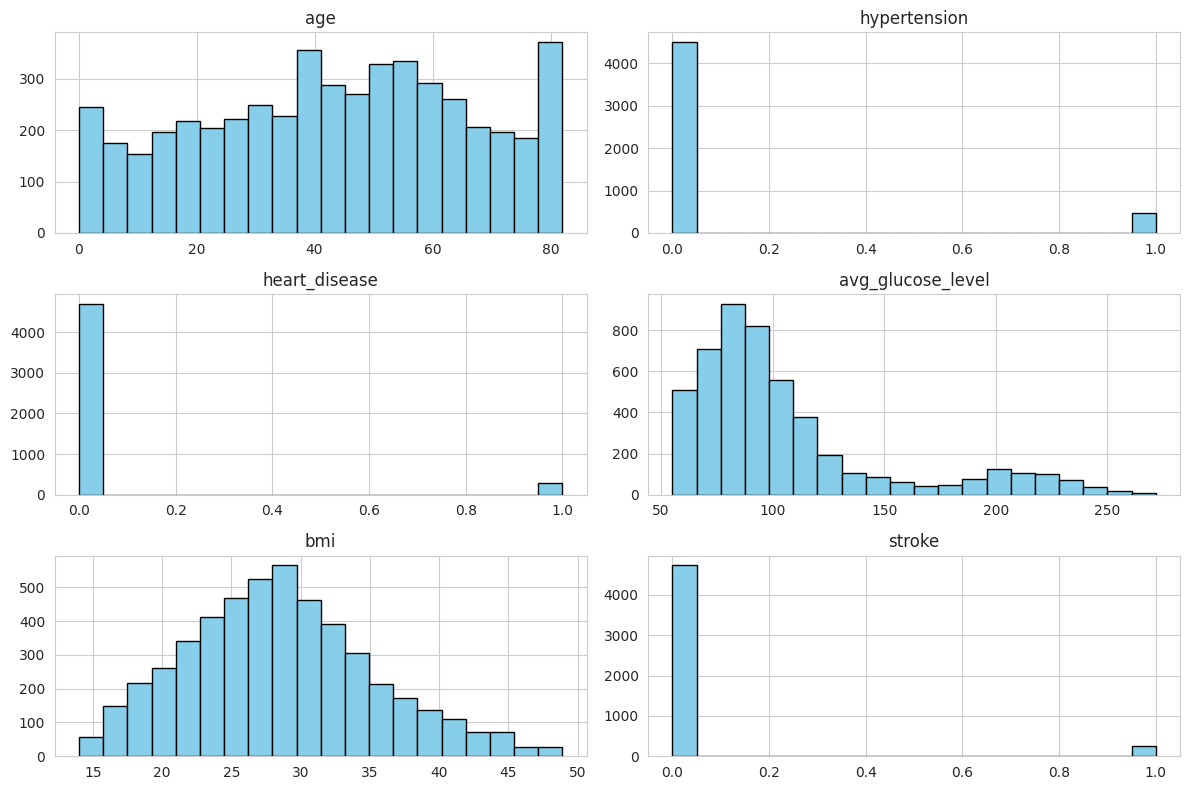

In [13]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

sns.set_style("whitegrid")

df[num_cols].hist(figsize=(12, 8), bins=20, color="skyblue", edgecolor="black")

plt.tight_layout()
plt.show()

In [14]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(df[col].value_counts())
    print("------"*5)

gender
Female    2907
Male      2074
Name: count, dtype: int64
------------------------------
ever_married
Yes    3280
No     1701
Name: count, dtype: int64
------------------------------
work_type
Private          2860
Self-employed     804
children          673
Govt_job          644
Name: count, dtype: int64
------------------------------
Residence_type
Urban    2532
Rural    2449
Name: count, dtype: int64
------------------------------
smoking_status
never smoked       1838
Unknown            1500
formerly smoked     867
smokes              776
Name: count, dtype: int64
------------------------------


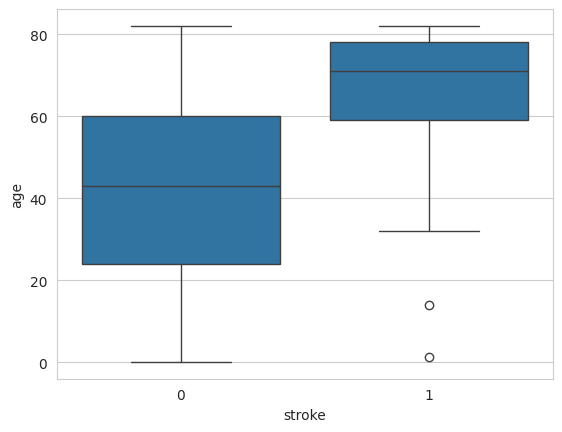

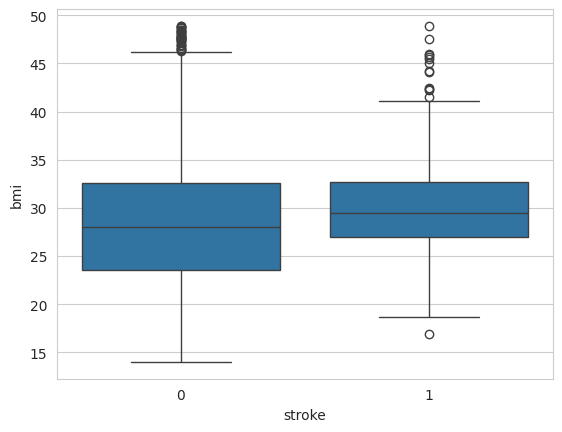

<Axes: xlabel='stroke', ylabel='avg_glucose_level'>

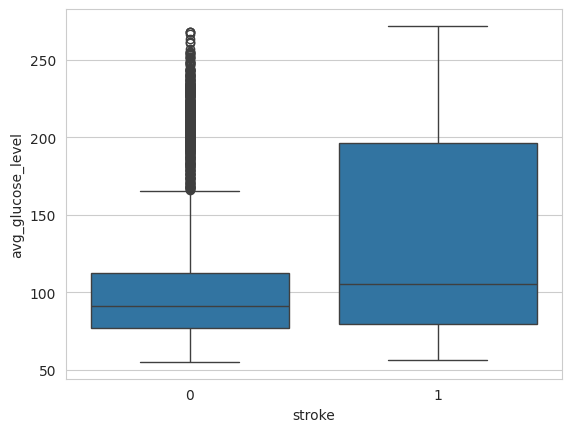

In [20]:
sns.boxplot(x="stroke", y="age", data=df)
plt.show()
sns.boxplot(x="stroke", y="bmi", data=df)
plt.show()
sns.boxplot(x="stroke", y="avg_glucose_level", data=df)


In [21]:
pd.crosstab(df["smoking_status"], df["stroke"], normalize="index")

stroke,0,1
smoking_status,,
Unknown,0.968667,0.031333
formerly smoked,0.919262,0.080738
never smoked,0.951578,0.048422
smokes,0.945876,0.054124


<Axes: >

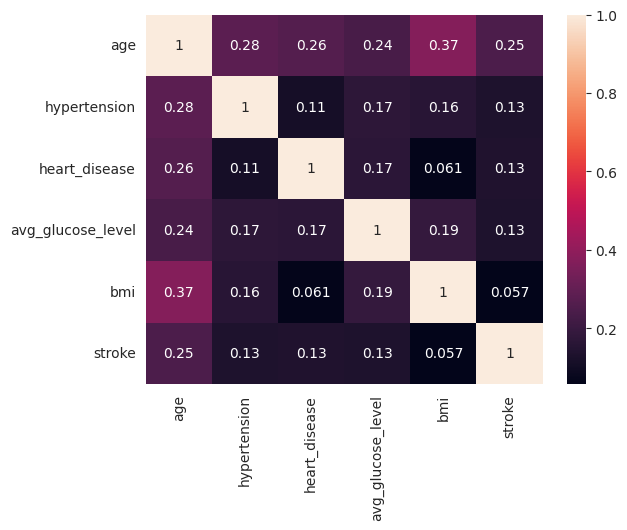

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True)